<a href="https://colab.research.google.com/github/Algoscribe/qml/blob/main/Hackathon__Qisket_finalcode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#BB84 Protocol: A Quantum Guide to Secure Key Distribution


## STEP 1: Qiskit Environment Setup

In this step, a modern quantum simulation environment is initialized using **Qiskit 2.x**, following the post-2025 execution architecture based on **Qiskit Primitives**. This environment forms the foundation for implementing and analyzing the **BB84 Quantum Key Distribution (QKD)** protocol under realistic noisy channel conditions.

Unlike legacy Qiskit workflows that relied on direct backend execution methods, this implementation strictly follows the **SamplerV2 primitive pipeline**, which is mandatory in 2026 for extracting **raw measurement bitstrings** required for cryptographic key generation.

---

### Qiskit Components and Their Roles

#### 1. Core Qiskit SDK (Unified Qiskit 2.x)
The core Qiskit SDK is used to construct quantum circuits representing BB84 state preparation, basis selection, and measurement. It enables:
- Creation of single qubit quantum circuits  
- Application of **Hadamard (H)** gates for basis selection  
- Application of **Pauli-X (X)** gates for bit encoding  
- Definition of measurement operations  

This layer provides a backend-independent representation of the BB84 protocol.

---

#### 2. Qiskit Aer Simulator
Qiskit Aer provides a high performance quantum simulation engine capable of modeling both ideal and noisy quantum systems. In this notebook, Aer is accessed **indirectly through the SamplerV2 primitive**, ensuring compatibility with the modern execution pipeline.

---

#### 3. Density Matrix Simulation Method
The simulator is configured to use the **density matrix** method. This is essential for QKD simulations because:
- Real quantum channels introduce decoherence and noise  
- Noise leads to **mixed quantum states**  
- Density matrices correctly model **non-unitary quantum processes**  

Statevector simulation is avoided, as it cannot accurately represent noisy quantum channels.

---

#### 4. Quantum Noise Modeling
A realistic noise model is constructed using Qiskit Aer’s noise framework. Noise is applied at the gate and measurement levels using physically valid Kraus operators. The modeled noise sources include:

- **Depolarizing Noise** – simulates random environmental interactions during transmission  
- **Phase-Flip (Z) Noise** – models phase instability in optical fiber channels  
- **Measurement (Readout) Noise** – represents detector and electronics errors  

Noise is explicitly applied to the **H** and **X** gates used in BB84, as well as to all measurement operations. This enables controlled analysis of the **Quantum Bit Error Rate (QBER)**.

---

#### 5. Qiskit Primitives – SamplerV2
The **SamplerV2** primitive is used as the execution interface for all quantum circuits. This represents the modern Qiskit execution model and replaces legacy execution methods.

Key advantages include:
- Direct access to raw measurement samples (bitstrings)  
- Backend-agnostic execution  
- Native support for noisy simulations via backend options  
- Forward compatibility with future Qiskit releases  

The noise model and simulation method are injected through the Sampler’s backend options, ensuring noise is applied during execution rather than circuit construction.

---

### Supporting Classical Libraries

- **NumPy** is used for classical post-processing such as bit manipulation, key sifting, and QBER computation  
- **Matplotlib** is used for visualizing protocol performance and error statistics  
- **Pandas** supports structured data analysis  
- **Qiskit Visualization** tools enable histogram based inspection of measurement outcomes  
- **ipywidgets** provide infrastructure for interactive dashboards in later stages  

---

### Significance of This Setup

This step establishes a realistic and future-proof virtual quantum communication environment where:
- Open-system quantum dynamics are correctly modeled  
- Noise effects are physically meaningful and configurable  
- Measurement statistics are extracted using the officially supported primitive interface  

This ensures that all subsequent stages of the BB84 protocol—key generation, sifting, error estimation, and eavesdropping detection are based on a scientifically valid quantum simulation framework.


In [ ]:
!pip install qiskit qiskit-aer


In [ ]:
import qiskit
import qiskit_aer

print("Qiskit version:", qiskit.__version__)
print("Qiskit Aer version:", qiskit_aer.__version__)


Qiskit version: 2.3.0
Qiskit Aer version: 0.17.2


In [ ]:
# STEP 1: Qiskit Environment Setup

# Core Qiskit SDK (Unified 2.x structure)
from qiskit import QuantumCircuit

# Qiskit Aer Simulator
from qiskit_aer import AerSimulator
# SamplerV2 is mandatory in 2026 for extracting raw bitstrings for QKD keys
from qiskit_aer.primitives import SamplerV2 as Sampler

# Qiskit Noise Modeling
from qiskit_aer.noise import NoiseModel, ReadoutError
from qiskit_aer.noise.errors import depolarizing_error, pauli_error

# Classical utilities
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # Moved from other steps

# Qiskit Visualization (moved from Step 7)
from qiskit.visualization import plot_histogram

# ipywidgets for interactive dashboards (moved from Step 11)
import ipywidgets as widgets
from ipywidgets import interactive_output, VBox, HBox

# -------------------------------
# Initialize Quantum Simulator
# -------------------------------
# We initialize a clean backend; noise is applied via Primitives in 2026
quantum_backend = AerSimulator(method="density_matrix")

# -------------------------------
# Define Quantum Noise Model
# -------------------------------

noise_model = NoiseModel()

# Depolarizing noise (quantum channel decoherence)
p_depolarize = 0.02
depol_error = depolarizing_error(p_depolarize, 1)

# Phase-flip noise using Pauli error
p_phase = 0.01
phase_error = pauli_error([('Z', p_phase), ('I', 1 - p_phase)])

# Measurement (readout) noise
p_meas = 0.01
readout_error = ReadoutError(
    [[1 - p_meas, p_meas],
     [p_meas, 1 - p_meas]]
)

# Apply noise to quantum operations
# Specifically targeting gates used in BB84 (H for basis, X for bit encoding)
noise_model.add_all_qubit_quantum_error(depol_error, ['h', 'x'])
noise_model.add_all_qubit_quantum_error(phase_error, ['h'])
noise_model.add_all_qubit_readout_error(readout_error)

# -------------------------------
# Initialize Modern Execution Pipeline
# -------------------------------
# Setup the Sampler with the noise model as a backend option
# This replaces the old "binding" method for noisy simulations
sampler = Sampler(
    options={"backend_options": {"noise_model": noise_model, "method": "density_matrix"}}
)

# The pass manager (pm) was for transpilation but is not explicitly used in this notebook's execution flow.
# It is removed as requested.

print(f"Qiskit {qiskit.__version__} environment initialized successfully.")
print("Modern V2 Sampler pipeline ready for BB84 key distribution.")

Qiskit 2.3.0 environment initialized successfully.
Modern V2 Sampler pipeline ready for BB84 key distribution.


## STEP 2: User-Defined BB84 Parameters

### Purpose
This step collects and validates the **user-defined parameters** that control the execution of the BB84 Quantum Key Distribution (QKD) protocol. These parameters determine the size of the quantum transmission, the presence of adversarial entities, and the physical characteristics of the quantum communication channel.

All subsequent stages including quantum state preparation, noisy transmission, eavesdropping simulation, measurement, key sifting, and QBER evaluation depend directly on the values defined in this step.

---

### Parameter Input and Validation

To ensure robustness and prevent invalid configurations, all inputs are obtained through **validated input functions** that enforce strict numerical bounds. This avoids undefined behavior during quantum circuit construction and execution.

---

### Parameters Defined

#### 1. Number of Qubits (`num_qubits`)
This parameter specifies the total number of qubits (photons) transmitted from the sender (Alice) to the receiver (Bob).

- Each qubit encodes **one classical bit (0 or 1)**  
- Encoding is performed using either the **Z-basis (computational basis)** or the **X-basis (Hadamard basis)**  
- The value is restricted to the range **1–32** to balance statistical relevance with simulation feasibility  

A larger number of qubits results in a longer raw key and more reliable statistical estimates but increases computational complexity.

---

#### 2. Number of Eavesdroppers (`num_eves`)
This parameter defines the number of adversarial entities (Eves) attempting to intercept the quantum channel.

- Allowed range: **0–5**
- Each eavesdropper is assumed to perform an **intercept–resend attack**
- Eavesdroppers measure qubits in randomly chosen bases and retransmit them  

The presence of one or more eavesdroppers introduces disturbance into the quantum channel, which later manifests as an increase in the **Quantum Bit Error Rate (QBER)**.

---

#### 3. Channel Distance (`channel_distance_km`)
This parameter represents the physical length of the quantum communication channel in kilometers, such as an optical fiber link.

- Allowed range: **0–100 km**
- Increasing distance leads to increased photon loss due to absorption and scattering  

Photon transmission probability is governed by the standard fiber attenuation model:

$$
\eta(d) = 10^{-\frac{\alpha d}{10}}
$$

where:
- $\eta(d)$ is the probability that a photon successfully reaches the receiver  
- $\alpha$ is the fiber attenuation coefficient (dB/km)  
- $d$ is the channel distance (km)  

In this virtual laboratory, the maximum distance is capped at **100 km**, reflecting realistic BB84 operation limits in fiber-based systems without quantum repeaters.


---

### Implementation Notes

- Integer and floating point inputs are handled separately to ensure type safety  
- All parameters are echoed back to the user for verification before execution proceeds  
- No quantum circuits are constructed at this stage; this step strictly defines the **experimental configuration**

---

### Relation to the BB84 Protocol
The parameters defined in this step directly influence:
- The number of quantum states prepared by Alice  
- The strength and detectability of eavesdropping  
- The effective loss and noise experienced during transmission  

By randomizing basis choices and enforcing strict quantum measurement rules in later steps, the BB84 protocol guarantees that any eavesdropping activity introduces detectable errors, enabling secure key generation.


In [ ]:
# STEP 2: Get User Input Parameters

def get_int_input(prompt, min_val, max_val):
    """
    Safely obtain an integer input within a specified range.
    """
    while True:
        try:
            value = int(input(prompt))
            if min_val <= value <= max_val:
                return value
            else:
                print(f"Please enter a value between {min_val} and {max_val}.")
        except ValueError:
            print("Invalid input. Please enter an integer.")


def get_float_input(prompt, min_val, max_val):
    """
    Safely obtain a floating-point input within a specified range.
    """
    while True:
        try:
            value = float(input(prompt))
            if min_val <= value <= max_val:
                return value
            else:
                print(f"Please enter a value between {min_val} and {max_val}.")
        except ValueError:
            print("Invalid input. Please enter a number.")


# -------------------------------
# User-defined BB84 parameters
# -------------------------------
num_qubits = get_int_input(
    "Enter number of qubits (1–32): ", 1, 32
)

num_eves = get_int_input(
    "Enter number of eavesdroppers (0–5): ", 0, 5
)

channel_distance_km = get_float_input(
    "Enter channel distance in km (0–100): ", 0.0, 100.0
)

print("\nBB84 Protocol Parameters Configured:")
print(f"Number of qubits        : {num_qubits}")
print(f"Number of eavesdroppers : {num_eves}")
print(f"Channel distance (km)   : {channel_distance_km}")

Enter number of qubits (1–32): 10
Enter number of eavesdroppers (0–5): 1
Enter channel distance in km (0–100): 12

BB84 Protocol Parameters Configured:
Number of qubits        : 10
Number of eavesdroppers : 1
Channel distance (km)   : 12.0


## STEP 3: Alice Encodes Secret Bits

### Purpose
In this step, Alice encodes classical secret bits into quantum states according to the **BB84 Quantum Key Distribution protocol**. Each classical bit is converted into a single-qubit quantum state using a randomly chosen measurement basis, ensuring security through quantum uncertainty.

This step models Alice’s role as the **sender** in BB84, responsible for preparing polarized photons for transmission over a quantum channel.

---

### TRUE BB84 Encoding Principle
The BB84 protocol relies on two key randomness properties:

- Each qubit has a **50% probability of being encoded in the Z-basis** and a **50% probability of being encoded in the X-basis**
- **Bit values and basis choices are statistically independent**

This independence is essential for detecting eavesdropping through error analysis.

---

### Secret Bit Selection
Alice manually enters a sequence of classical secret bits (0 or 1), one for each qubit.  
These bits represent Alice’s **raw secret key** prior to transmission.

Manual entry is used in this virtual laboratory to:
- Maintain transparency of the protocol
- Allow controlled experimentation and debugging
- Clearly demonstrate the encoding logic for educational and analytical purposes

---

### Random Basis Selection
For each qubit, Alice independently selects a random basis:

- `0` → **Z-basis (Rectilinear basis)**
- `1` → **X-basis (Diagonal basis)**

The basis choices are generated using a uniform random process and are independent of the chosen bit values, satisfying the TRUE BB84 requirement.

---

### BB84 Quantum State Encoding

Each (bit, basis) pair is encoded into a quantum state using Qiskit gates as follows:
#### Z-basis (Rectilinear)

- Bit `0` → Horizontal polarization (→)
$$
\lvert 0 \rangle
$$


- Bit `1` →  Vertical polarization (↑)
$$
\lvert 1 \rangle
$$


---

#### X-basis (Diagonal)

- Bit `0` → +45° polarization (↗)
$$
\lvert + \rangle = H \lvert 0 \rangle
$$


- Bit `1` → −45° polarization (↘)
$$
\lvert - \rangle = H \lvert 1 \rangle
$$


---


### Quantum Circuit Implementation
Each qubit is implemented as a **single-qubit Qiskit `QuantumCircuit`**:

- The **Pauli-X gate (X)** encodes bit value `1`
- The **Hadamard gate (H)** switches encoding from the Z-basis to the X-basis

Encoding logic:
- Bit encoding is applied **first**
- Basis transformation is applied **afterward**
This encoding correctly prepares all four BB84 quantum states:

$$
\lvert 0 \rangle,\;
\lvert 1 \rangle,\;
\lvert + \rangle,\;
\lvert - \rangle
$$


---

### Demonstration Output
For visualization and verification, the quantum circuits for the **first five qubits** are displayed, showing:
- Bit value
- Chosen basis
- Corresponding photon polarization
- Exact quantum gate sequence

Remaining circuits are omitted for brevity when the number of qubits exceeds five.

---

### Security Significance
Random basis selection ensures that:
- When Alice and Bob choose the **same basis**, their measurement outcomes are correlated
- When bases differ, measurement outcomes are random
- Any eavesdropper measuring in the wrong basis introduces detectable disturbances

This disturbance is later quantified using the **Quantum Bit Error Rate (QBER)**, enabling reliable detection of eavesdropping.

---

### Key Takeaways
- Same bit value can be encoded in different bases
- Different bit values can use the same basis
- Basis choice is unknown to any eavesdropper
- This randomness forms the core security guarantee of the BB84 protocol


In [ ]:

# STEP 3: Alice Encodes Secret Bits


print("STEP 3: Alice entering secret bits...\n")

# -------------------------------
# Alice manually enters secret bits
# -------------------------------
alice_bits = []

print("Alice, please enter a secret value (0 or 1) for each qubit:")
for i in range(num_qubits):
    while True:
        try:
            bit = int(input(f"Value for qubit {i+1}: "))
            if bit in [0, 1]:
                alice_bits.append(bit)
                break
            else:
                print("Invalid input. Enter 0 or 1.")
        except ValueError:
            print("Invalid input. Enter a number.")

print("\n✓ Alice's bits entered.\n")

# -------------------------------
# Generate RANDOM bases (TRUE BB84)
# -------------------------------
alice_bases = np.random.randint(0, 2, num_qubits)
print("Alice's random basis choices:")
print(alice_bases, "(0 = Z-basis, 1 = X-basis)\n")

# -------------------------------
# Qiskit-based BB84 encoding
# -------------------------------
def encode_bb84_qubit(bit, basis):
    """
    Encode a classical bit into a BB84 quantum state using Qiskit.
    """
    qc = QuantumCircuit(1, 1)

    # Encode bit
    if bit == 1:
        qc.x(0)

    # Encode basis
    if basis == 1:
        qc.h(0)

    return qc


alice_circuits = []
for bit, basis in zip(alice_bits, alice_bases):
    qc = encode_bb84_qubit(bit, basis)
    alice_circuits.append(qc)

print("✓ Alice has encoded bits into BB84 quantum states.\n")

# -------------------------------
# Display quantum circuits (demo)
# -------------------------------
print("--- Quantum Circuit Encoding Demonstration (First 5 Qubits) ---\n")

display_limit = min(5, num_qubits)

for i in range(display_limit):
    qc = alice_circuits[i]
    basis_name = "Z-basis (Rectilinear)" if alice_bases[i] == 0 else "X-basis (Diagonal)"

    if alice_bases[i] == 0:
        polarization = "Horizontal (→)" if alice_bits[i] == 0 else "Vertical (↑)"
    else:
        polarization = "+45° (↗)" if alice_bits[i] == 0 else "-45° (↘)"

    print(f"Qubit {i+1}:")
    print(f"  Bit value   : {alice_bits[i]}")
    print(f"  Basis       : {basis_name}")
    print(f"  Polarization: {polarization}")
    print("  Quantum circuit:")
    print(qc.draw(output="text"))
    print()

if num_qubits > 5:
    print(f"... Circuits for remaining {num_qubits - 5} qubits not shown for brevity.\n")

print("✓ TRUE BB84 encoding demonstrated:")
print("  • Random basis selection")
print("  • Basis independent of bit value")
print("  • Same bit can be encoded in different bases")
print("  • This randomness enables eavesdropping detection")


STEP 3: Alice entering secret bits...

Alice, please enter a secret value (0 or 1) for each qubit:
Value for qubit 1: 1
Value for qubit 2: 1
Value for qubit 3: 1
Value for qubit 4: 1
Value for qubit 5: 0
Value for qubit 6: 1
Value for qubit 7: 0
Value for qubit 8: 1
Value for qubit 9: 0
Value for qubit 10: 1

✓ Alice's bits entered.

Alice's random basis choices:
[1 1 1 1 0 0 1 1 0 1] (0 = Z-basis, 1 = X-basis)

✓ Alice has encoded bits into BB84 quantum states.

--- Quantum Circuit Encoding Demonstration (First 5 Qubits) ---

Qubit 1:
  Bit value   : 1
  Basis       : X-basis (Diagonal)
  Polarization: -45° (↘)
  Quantum circuit:
     ┌───┐┌───┐
  q: ┤ X ├┤ H ├
     └───┘└───┘
c: 1/══════════
               

Qubit 2:
  Bit value   : 1
  Basis       : X-basis (Diagonal)
  Polarization: -45° (↘)
  Quantum circuit:
     ┌───┐┌───┐
  q: ┤ X ├┤ H ├
     └───┘└───┘
c: 1/══════════
               

Qubit 3:
  Bit value   : 1
  Basis       : X-basis (Diagonal)
  Polarization: -45° (↘)
  Quan

## STEP 4: Quantum Channel Attenuation (Photon Loss)

### Purpose
In this step, distance-dependent **photon loss** in the quantum communication channel is modeled. Photon loss is a **classical environmental effect** caused by absorption and scattering in optical fiber. It reduces the number of photons reaching the receiver (Bob) but does **not constitute a quantum measurement**.

This step determines which of Alice’s encoded qubits survive transmission and are eligible for further processing in the BB84 protocol.

---

### Physical Channel Model
Optical fiber attenuation is characterized by an exponential decay in photon transmission probability with distance. The channel is assumed to be a standard telecom optical fiber with a constant attenuation coefficient.

The attenuation coefficient is defined as:

$$
\alpha = 0.2 \; \text{dB/km}
$$

The channel distance is denoted by:

$$
d \; (\text{km})
$$

---

### Photon Survival Probability
The probability that a photon successfully reaches Bob is given by the standard fiber attenuation model:

$$
\eta(d) = 10^{-\frac{\alpha d}{10}}
$$

where:
- $\eta(d)$ is the photon survival probability  
- $\alpha$ is the fiber attenuation coefficient (dB/km)  
- $d$ is the channel distance (km)  

This model accurately represents photon absorption and scattering losses in real optical fibers.

---

### Interpretation of the Attenuation Model
- For small values of $d$, $\eta(d)$ is close to $1$, meaning most photons survive  
- As $d$ increases, $\eta(d)$ decreases exponentially  
- Photon loss increases rapidly at long distances  

Lost photons are **discarded** and do not participate in any later stages of the protocol.

---

### Expected Photon Statistics (Theoretical)
If Alice sends $N$ photons, the expected number of photons reaching Bob is:

$$
\mathbb{E}[N_{\text{received}}] = N \cdot \eta(d)
$$

This value represents a **statistical average** over many transmissions. Individual experimental runs may differ due to randomness.

---

### Monte Carlo Simulation of Photon Loss
Photon loss is implemented using a **Monte Carlo simulation**:

- Each photon is treated independently  
- A classical random number $r \in [0,1)$ is generated  
- A photon survives if:

$$
r < \eta(d)
$$

This randomness is **classical**, not quantum, and models environmental loss in the transmission medium.

---

### Data Reduction After Channel Loss
Only photons that survive the attenuation process are retained:

- Corresponding quantum circuits are preserved  
- Associated classical data (bits and bases) are filtered accordingly  
- Lost photons are permanently removed from the protocol  

These surviving photons are passed to subsequent steps involving potential eavesdropping and quantum measurement.

---

### Important Clarification
- **Classical randomness** → photon loss (this step)  
- **Quantum randomness** → measurement outcomes (later steps)  
- Photon loss affects the **key rate**, not the **Quantum Bit Error Rate (QBER)** directly  

This separation is essential for a physically correct BB84 simulation.

---

### Summary
This step models realistic quantum channel attenuation by:
- Applying a physically accurate fiber loss model  
- Removing lost photons before any quantum interaction  
- Preserving only valid quantum states for further protocol execution  

This ensures that subsequent BB84 stages operate on a realistic subset of transmitted qubits.


In [ ]:
# ===============================
# STEP 4: Quantum Channel Attenuation
# ===============================

print("\nSTEP 4: Quantum Channel Attenuation\n")
print("In this step, we model photon loss in an optical fiber.")
print("Photon loss is a classical environmental effect, not a quantum measurement.\n\n")

# -------------------------------------------------
# Step 4.1: Define physical channel parameters
# -------------------------------------------------
alpha_db_per_km = 0.2  # Standard telecom fiber attenuation

print(" Step 4.1: Physical Channel Parameters")
print("--------------------------------------")
print(f"• Fiber attenuation coefficient (α): {alpha_db_per_km} dB/km")
print(f"• Channel distance (d): {channel_distance_km} km\n")

# -------------------------------------------------
# Step 4.2: Photon survival probability calculation
# -------------------------------------------------
print(" Step 4.2: Photon Survival Probability Calculation")
print("--------------------------------------------------")
print("Photon transmission probability is given by:")
print("η(d) = 10^(-α × d / 10)\n")

print("Substituting the values:")
print(f"η(d) = 10^(-{alpha_db_per_km} × {channel_distance_km} / 10)")

exponent = -(alpha_db_per_km * channel_distance_km) / 10
print(f"Exponent = {exponent:.4f}")

eta_d = 10 ** exponent
print(f"η(d) = 10^{exponent:.4f} = {eta_d:.4f}\n")

print("Interpretation:")
print(f"• Each photon has a {eta_d*100:.2f}% probability of reaching Bob")
print(f"• Each photon has a {(1-eta_d)*100:.2f}% probability of being lost\n\n")

# -------------------------------------------------
# Step 4.3: Expected photon statistics (theoretical)
# -------------------------------------------------
print(" Step 4.3: Expected Photon Statistics (Theoretical Average)")
print("-----------------------------------------------------------")

expected_survivors = num_qubits * eta_d

print(f"• Total photons sent by Alice : {num_qubits}")
print(f"• Expected photons received  : {num_qubits} × {eta_d:.4f}")
print(f"                               ≈ {expected_survivors:.2f} photons\n")

print("Note:")
print("• This expected value is an average over many transmissions")
print("• A single experiment may differ due to randomness\n\n")

# -------------------------------------------------
# Step 4.4: Monte Carlo simulation of photon loss
# -------------------------------------------------
print("Step 4.4: Monte Carlo Simulation of Photon Loss")
print("------------------------------------------------")
print("Each photon is tested independently against η(d).")
print("This randomness is CLASSICAL and models environmental loss.\n\n")

surviving_circuits = []
surviving_indices = []

for i, qc in enumerate(alice_circuits):
    r = np.random.rand()  # classical randomness
    if r < eta_d:
        surviving_circuits.append(qc)
        surviving_indices.append(i)

num_received = len(surviving_circuits)
num_lost = num_qubits - num_received

print("Simulation Outcome:")
print(f"• Photons received by Bob : {num_received}")
print(f"• Photons lost in channel : {num_lost}\n")

print("Why does this differ from the expected value?")
print("• Photon loss is probabilistic")
print("• Each run represents one random realization")
print("• Real optical fibers behave the same way\n\n")

# -------------------------------------------------
# Step 4.5: Retain only surviving quantum data
# -------------------------------------------------
alice_bits_survived = [alice_bits[i] for i in surviving_indices]
alice_bases_survived = [alice_bases[i] for i in surviving_indices]

print("Step 4.5: Preparing Data for Next Steps")
print("----------------------------------------")
print("✓ Lost photons are discarded")
print("✓ Only surviving photons continue to Eve and Bob\n\n")

print("IMPORTANT CLARIFICATION:")
print("• Classical randomness → photon loss (this step)")
print("• Quantum randomness  → measurement outcomes (later steps)")
print("• Qiskit will be used for quantum randomness in measurement\n\n")

print("✓ STEP 4 complete: Quantum channel attenuation modeled correctly.\n")


STEP 4: Quantum Channel Attenuation

In this step, we model photon loss in an optical fiber.
Photon loss is a classical environmental effect, not a quantum measurement.


 Step 4.1: Physical Channel Parameters
--------------------------------------
• Fiber attenuation coefficient (α): 0.2 dB/km
• Channel distance (d): 12.0 km

 Step 4.2: Photon Survival Probability Calculation
--------------------------------------------------
Photon transmission probability is given by:
η(d) = 10^(-α × d / 10)

Substituting the values:
η(d) = 10^(-0.2 × 12.0 / 10)
Exponent = -0.2400
η(d) = 10^-0.2400 = 0.5754

Interpretation:
• Each photon has a 57.54% probability of reaching Bob
• Each photon has a 42.46% probability of being lost


 Step 4.3: Expected Photon Statistics (Theoretical Average)
-----------------------------------------------------------
• Total photons sent by Alice : 10
• Expected photons received  : 10 × 0.5754
                               ≈ 5.75 photons

Note:
• This expected valu

## STEP 5: Alice’s Quantum Transmission Overview

### Purpose
This step provides a **clear, tabular overview** of Alice’s quantum transmission **before** any channel effects, photon loss, eavesdropping, or measurement take place. It allows direct inspection of how Alice’s classical secret bits and randomly chosen bases define the quantum states entering the channel.

This step is **purely observational** and does not modify the quantum data.

---

### What Is Displayed
For each photon prepared by Alice, the following information is shown:

- **Photon number** – index of the transmitted photon  
- **Alice Bit** – the classical secret bit value (0 or 1)  
- **Alice Basis** – the randomly chosen encoding basis  
  - `Z` → Rectilinear (computational) basis  
  - `X` → Diagonal (Hadamard) basis  

Each row corresponds to **one encoded qubit** prepared according to the BB84 protocol.

---

### Protocol State at This Stage
At this point in the BB84 workflow:

- Alice’s secret bits are fixed  
- Alice’s basis choices are fixed and random  
- Quantum circuits representing the encoded states have already been constructed  
- No photon loss has been applied  
- No eavesdropping has occurred  
- No measurements have been performed  

The quantum states shown here are exactly what Alice sends into the quantum channel.

---

### Why This Step Matters
Separating Alice’s transmission from later stages ensures:

- Clear protocol sequencing  
- Conceptual separation between **state preparation** and **channel effects**  
- Easier verification, debugging, and explanation  

In BB84, Alice’s random basis selection is the fundamental source of security. This step makes that randomness **explicit and visible** before any disturbances are introduced.

---

### Summary
This step serves as a transparent checkpoint that:

- Confirms correct BB84 encoding by Alice  
- Displays the raw transmission data entering the channel  
- Prepares the system for subsequent steps involving attenuation, eavesdropping, and measurement  

No quantum or classical randomness is introduced here beyond what has already been defined.


In [ ]:
# ===============================
# STEP 5: Alice’s Quantum Transmission Overview
# ===============================

print("STEP 5: Displaying Alice’s Quantum Transmission\n")

# Create a clean display table for Alice's transmission
alice_transmission_data = {
    "Photon #": range(1, num_qubits + 1),
    "Alice Bit": alice_bits,
    "Alice Basis": [
        "Z " if b == 0 else "X "
        for b in alice_bases
    ]
}

alice_df = pd.DataFrame(alice_transmission_data)

print("Alice has prepared the following quantum states:\n")
display(alice_df.style.hide(axis="index")) # Added .style.hide(axis="index") here

print("Explanation:")
print("• Each row corresponds to one photon sent by Alice")
print("• 'Alice Bit' is the classical secret bit")
print("• 'Alice Basis' is the randomly chosen encoding basis")
print("• These quantum states now enter the quantum channel\n")

print("✓ STEP 5 complete: Alice’s transmission displayed clearly.")

STEP 5: Displaying Alice’s Quantum Transmission

Alice has prepared the following quantum states:



Photon #,Alice Bit,Alice Basis
1,1,X
2,1,X
3,1,X
4,1,X
5,0,Z
6,1,Z
7,0,X
8,1,X
9,0,Z
10,1,X


Explanation:
• Each row corresponds to one photon sent by Alice
• 'Alice Bit' is the classical secret bit
• 'Alice Basis' is the randomly chosen encoding basis
• These quantum states now enter the quantum channel

✓ STEP 5 complete: Alice’s transmission displayed clearly.


## STEP 6: Eve’s Intercept–Resend Attack

### Purpose
This step simulates a **quantum intercept–resend attack** performed by one or more eavesdroppers (Eves) on the photons that survive channel attenuation. It demonstrates how unauthorized measurement of quantum states inevitably introduces disturbances that can later be detected by Alice and Bob.

This step models Eve’s interaction with the quantum channel **before Bob performs any measurements**.

---

### Attack Model
Each eavesdropper performs an **intercept–resend attack**, which proceeds as follows for every surviving photon:

1. Eve intercepts the photon in transit  
2. Eve randomly chooses a measurement basis  
   - Z-basis (computational basis)  
   - X-basis (Hadamard basis)  
3. Eve performs a **quantum measurement**, causing state collapse  
4. Eve prepares and resends a **new photon** based on her measurement outcome and chosen basis  

This process is repeated independently for each Eve and for each surviving photon.

---

### Quantum Mechanical Basis of the Attack
If Eve measures a photon using the **same basis** as Alice’s encoding basis, the original bit value is preserved.  
If Eve measures using a **different basis**, the measurement outcome is fundamentally random, and the original quantum state is destroyed.

This disturbance propagates forward and affects all later measurements.

---

### Implementation Details
- Eve’s basis choices are generated randomly and independently  
- Measurement is performed using the **SamplerV2 primitive**, ensuring true quantum measurement statistics  
- Each measurement causes **irreversible wavefunction collapse**  
- Eve resends a freshly prepared qubit corresponding to her measurement result  

All operations in this step are **quantum mechanical**, not classical approximations.

---

### Wrong-Basis Measurements
Let:
- $N_{\text{meas}}$ be the total number of measurements performed by Eve  
- $N_{\text{wrong}}$ be the number of times Eve’s chosen basis differs from Alice’s encoding basis  

The wrong-basis rate is given by:

$$
\text{Wrong-basis rate} = \frac{N_{\text{wrong}}}{N_{\text{meas}}}
$$

For a true intercept–resend attack with random basis selection, this rate approaches:

$$
\text{Wrong-basis rate} \approx 0.5
$$

---

### Educational Output Summary
This step reports:
- Total number of photons intercepted  
- Number of eavesdroppers involved  
- Total quantum measurements performed by Eve  
- Number and percentage of wrong basis measurements  

These values provide direct insight into how often Eve disturbs the quantum states.

---

### Security Implications
- Quantum states **cannot be copied without disturbance**  
- Eve’s measurements irreversibly alter many photons  
- These alterations later appear as **bit mismatches** when Bob measures the photons  
- A sufficiently high error rate signals the presence of an eavesdropper  

This phenomenon is a direct consequence of the **no-cloning theorem** and the incompatibility of quantum measurement bases.

---

### Important Clarification
- Eve’s randomness → **quantum randomness due to measurement**  
- Channel loss → **classical randomness handled earlier**  
- Bob has not yet measured the photons at this stage  

This separation preserves the physical correctness of the BB84 simulation.

---

### Summary
This step demonstrates that:
- Intercept–resend attacks necessarily disturb quantum states  
- Wrong-basis measurements occur with high probability  
- Eve’s presence becomes statistically detectable  

This forms the core security guarantee of the BB84 protocol.


In [ ]:
# ================================================================
# STEP 6: Eve Intercept–Resend Attack (Quantum, Educational Output)
# ================================================================

print("STEP 6: Eve Intercept–Resend Attack (Quantum)\n")

if num_eves == 0:
    print("No eavesdroppers present.")
    post_eve_circuits = surviving_circuits
    print("✓ Qubits travel undisturbed to Bob.\n")

else:
    post_eve_circuits = surviving_circuits
    total_qubits = len(post_eve_circuits)
    total_measurements = 0
    wrong_basis_count = 0

    if total_qubits > 0:
        for _ in range(num_eves):
            new_circuits = []

            for qc, alice_basis in zip(post_eve_circuits, alice_bases_survived):
                eve_qc = qc.copy()

                # Eve randomly chooses a basis: 0 = Z (Computational), 1 = X (Hadamard)
                eve_basis = np.random.randint(0, 2)
                total_measurements += 1

                if eve_basis != alice_basis:
                    wrong_basis_count += 1

                # If Eve chooses X basis, apply H gate before measurement
                if eve_basis == 1:
                    eve_qc.h(0)

                # Quantum measurement (This causes state collapse)
                eve_qc.measure(0, 0)

                # --- SamplerV2 Execution Fix ---
                job = sampler.run([eve_qc])
                result = job.result()

                # Accessing the first PUB result
                pub_result = result[0]

                # Retrieve the classical register name (usually 'c', 'char', or 'meas')
                # We extract the counts from the first available register in the DataBin
                reg_name = list(pub_result.data.keys())[0]
                counts = pub_result.data[reg_name].get_counts()

                # Get the bit value (since shots=1, we just take the only key present)
                measured_bit_str = list(counts.keys())[0]
                measured_bit = int(measured_bit_str)

                # Eve resends a freshly prepared qubit based on her measurement
                resend_qc = QuantumCircuit(1, 1)
                if measured_bit == 1:
                    resend_qc.x(0)
                if eve_basis == 1:
                    resend_qc.h(0)

                new_circuits.append(resend_qc)

            post_eve_circuits = new_circuits

    # -------------------------------
    # Educational summary
    # -------------------------------
    if total_measurements > 0:
        mismatch_rate = (wrong_basis_count / total_measurements) * 100
    else:
        mismatch_rate = 0.0

    print("Intercept–Resend Summary:")
print("-------------------------")

print(f"• Total photons intercepted         : {total_qubits}")
print("  → Number of quantum bits sent by Alice that Eve tried to spy on.")

print(f"\n• Number of eavesdroppers (Eves)     : {num_eves}")
print("  → Each Eve independently measures and resends the photons.")

print(f"\n• Total quantum measurements by Eve : {total_measurements}")
print("  → Every measurement means Eve touched and disturbed a quantum state.")

print(f"\n• Wrong-basis measurements          : {wrong_basis_count}")
print("  → These measurements force photons into random states.")

if total_measurements > 0:
    mismatch_rate = (wrong_basis_count / total_measurements) * 100
    print(f"  → This is {mismatch_rate:.2f}% of Eve’s measurements.")
    print("  → Around 50% is expected in a real intercept–resend attack.")

if total_qubits == 0:
    print("\n⚠ No photons reached Eve due to channel loss.")

print("\nWhat physically happens:")
print("• Eve measures each photon using a randomly chosen basis.")
print("• Choosing the wrong basis destroys the original quantum information.")
print("• Eve then sends a newly prepared photon based on her result.")

print("\nWhy this creates errors:")
print("• Bob receives disturbed photons instead of Alice’s originals.")
print("• These disturbances appear as bit mismatches during key comparison.")
print("• A high error rate warns Alice and Bob that eavesdropping occurred.")

print("\nSecurity insight:")
print("• Quantum states cannot be copied without disturbance.")
print("• Eve’s presence is revealed by the errors she introduces.")

print("\n✓ Quantum intercept–resend attack successfully demonstrated.\n")


STEP 6: Eve Intercept–Resend Attack (Quantum)

Intercept–Resend Summary:
-------------------------
• Total photons intercepted         : 8
  → Number of quantum bits sent by Alice that Eve tried to spy on.

• Number of eavesdroppers (Eves)     : 1
  → Each Eve independently measures and resends the photons.

• Total quantum measurements by Eve : 8
  → Every measurement means Eve touched and disturbed a quantum state.

• Wrong-basis measurements          : 3
  → These measurements force photons into random states.
  → This is 37.50% of Eve’s measurements.
  → Around 50% is expected in a real intercept–resend attack.

What physically happens:
• Eve measures each photon using a randomly chosen basis.
• Choosing the wrong basis destroys the original quantum information.
• Eve then sends a newly prepared photon based on her result.

Why this creates errors:
• Bob receives disturbed photons instead of Alice’s originals.
• These disturbances appear as bit mismatches during key comparison.
• A

## STEP 7: Bob’s Reception and Measurement

### Purpose
This step models Bob’s role in the BB84 protocol, where he receives the surviving photons and performs **quantum measurements** on them. It represents the final quantum interaction before classical post-processing begins.

Bob’s measurements convert quantum states into classical bits, revealing the combined effects of:
- Channel attenuation (photon loss)
- Eve’s intercept–resend attack
- Quantum measurement randomness

---

### Protocol State Before Measurement
At the beginning of this step:

- Alice has encoded all qubits
- Photon loss has already removed some qubits
- Eve (if present) has intercepted and resent photons
- Bob receives **only the surviving photons**

Lost photons do **not** produce measurement outcomes.

---

### Bob’s Basis Selection
For each received photon, Bob independently and randomly selects a measurement basis:

- Z-basis (computational basis)
- X-basis (Hadamard basis)

Bob’s basis choices are independent of both Alice’s and Eve’s choices.

---

### Quantum Measurement
Each received qubit is measured using a true quantum measurement simulated by Qiskit:

- Measurement causes **wavefunction collapse**
- The result is a classical bit value:  
  $$
  0 \quad \text{or} \quad 1
  $$

If Bob measures in the **same basis** used by Alice:
- The correct bit is obtained **unless Eve disturbed the state**

If Bob measures in a **different basis**:
- The outcome is fundamentally random

This randomness arises from quantum mechanics, not classical noise.

---

### Measurement Results Table
This step displays a table containing:

- Photon index
- Alice’s original bit (for surviving photons)
- Alice’s encoding basis
- Bob’s measurement basis
- Bob’s measured bit

This table allows direct comparison of preparation and measurement outcomes.

---

### Relation to Channel Distance
Photon loss increases with channel distance according to the attenuation model:

$$
\eta(d) = 10^{-\frac{\alpha d}{10}}
$$

As distance increases:
- Fewer photons reach Bob
- The number of Bob’s measurement results decreases
- The **key rate** is reduced

Photon loss explains why Bob receives fewer bits than Alice originally sent.

---

### Important Clarifications
- Photon loss is a **classical effect** and does not create bit errors  
- Bit errors arise from **basis mismatch** and **eavesdropping disturbance**  
- Bob performs **one quantum measurement per photon**  
- Each measurement produces **one random outcome**

No repetition (shots) is used for individual qubit measurements in this protocol simulation.

---

### Summary
This step demonstrates that:

- Bob’s measurements collapse quantum states into classical bits
- Channel loss reduces the number of usable qubits
- Eve’s interference causes incorrect measurement results
- Quantum randomness is unavoidable and fundamental

These results prepare the system for **key sifting and error analysis** in the next steps of the BB84 protocol.


STEP 7: Bob measuring received qubits


Bob's Measurement Results:



Photon #,Alice Bit,Alice Basis,Bob Basis,Bob Bit
1,1,X,Z,0
2,1,X,X,1
3,1,X,X,1
4,1,Z,X,1
5,0,X,Z,1
6,1,X,X,1
7,0,Z,Z,0
8,1,X,Z,0




Reception Summary:
• Photons received by Bob : 8
• Photons lost in channel : 2


🔍 WHAT JUST HAPPENED?

1. Bob used a random 'ruler' (Basis) to measure each incoming photon.

2. If Bob's basis matches Alice's, he should get her bit... UNLESS Eve disturbed it.

3. If Eve measured in the wrong basis (Step 6), she 'flipped' the state, and Bob might
   get a wrong bit even if his basis matches Alice's!



Overall Measurement Outcomes (Histogram):



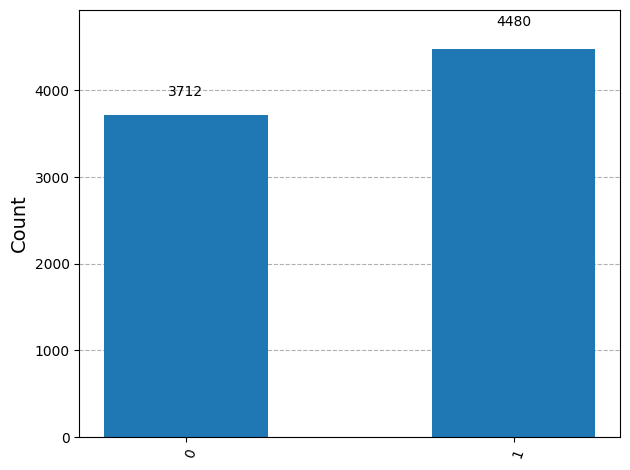


This histogram shows the total number of 0s and 1s Bob recorded.
IMPORTANT INTERPRETATION NOTE:
-------------------------------

• Although the original message contained only a small number of photons,
  each quantum circuit is executed MANY times by the simulator.

• These repeated executions are called 'shots'.
• A single shot means running the SAME quantum measurement once.

Understanding shots and the number 1024:
-----------------------------------------

• Quantum measurements are probabilistic, not deterministic.
• So the simulator repeats the same measurement many times to estimate probabilities.

• In this simulation, the number of shots is 1024.
• This means EACH quantum circuit is executed and measured 1024 times.

• Relationship between shots and histogram counts:

  → Shots = 1024 repetitions of the same experiment
  → Each repetition produces one result (0 or 1)

  → Histogram counts are the total of these 1024 results

• Why not just 1 shot?

  → A single shot gives on

In [ ]:
# ================================================================
# STEP 7: Bob's Reception and Measurement
# ================================================================

print("STEP 7: Bob measuring received qubits\n\n")

# Bob randomly chooses measurement bases
bob_bases = np.random.randint(0, 2, len(post_eve_circuits))  # 0 = Z, 1 = X
bob_bits = []

# Store raw counts for histogram
all_bob_counts = []

for qc, basis in zip(post_eve_circuits, bob_bases):
    bob_qc = qc.copy()

    # Apply Bob's basis choice
    if basis == 1:
        bob_qc.h(0)

    # Quantum measurement (true quantum randomness)
    bob_qc.measure(0, 0)

    # --- SamplerV2 Execution Fix ---
    job = sampler.run([bob_qc])
    result = job.result()

    # Access the first result in the PrimitiveResult object
    pub_result = result[0]

    # Dynamically find the register name (usually 'c' or 'meas')
    # We extract the counts from the first available register in the DataBin
    reg_name = list(pub_result.data.keys())[0]
    counts = pub_result.data[reg_name].get_counts()

    # Get the bit value (since shots=1, we just take the only key present)
    measured_bit = int(list(counts.keys())[0])
    # --- END FIX ---

    bob_bits.append(measured_bit)
    all_bob_counts.append(counts)

# -------------------------------
# Display Bob's reception results
# -------------------------------
bob_df = pd.DataFrame({
    "Photon #": range(1, len(bob_bits) + 1),
    "Alice Bit": alice_bits_survived,
    "Alice Basis": [
        "Z" if b == 0 else "X" for b in alice_bases_survived
    ],
    "Bob Basis": [
        "Z" if b == 0 else "X" for b in bob_bases
    ],
    "Bob Bit": bob_bits
})

print("Bob's Measurement Results:\n")
display(bob_df.style.hide(axis="index"))

print("\n\nReception Summary:")
print(f"• Photons received by Bob : {len(bob_bits)}")
print(f"• Photons lost in channel : {num_qubits - len(bob_bits)}\n\n")

print("🔍 WHAT JUST HAPPENED?\n")
print("1. Bob used a random 'ruler' (Basis) to measure each incoming photon.\n")
print("2. If Bob's basis matches Alice's, he should get her bit... UNLESS Eve disturbed it.\n")
print("3. If Eve measured in the wrong basis (Step 6), she 'flipped' the state, and Bob might")
print("   get a wrong bit even if his basis matches Alice's!\n\n")

# -------------------------------
# Visualize Bob's measurement outcomes
# -------------------------------
if bob_bits:
    aggregated_counts = {}
    for counts in all_bob_counts:
        for bit, count in counts.items():
            aggregated_counts[bit] = aggregated_counts.get(bit, 0) + count

    if aggregated_counts:
        print("\nOverall Measurement Outcomes (Histogram):\n")
        fig = plot_histogram(aggregated_counts)
        display(fig)
        print("\nThis histogram shows the total number of 0s and 1s Bob recorded.")
        print("IMPORTANT INTERPRETATION NOTE:")
        print("-------------------------------\n")

        print("• Although the original message contained only a small number of photons,")
        print("  each quantum circuit is executed MANY times by the simulator.\n")

        print("• These repeated executions are called 'shots'.")
        print("• A single shot means running the SAME quantum measurement once.\n")

        print("Understanding shots and the number 1024:")
        print("-----------------------------------------\n")
        print("• Quantum measurements are probabilistic, not deterministic.")
        print("• So the simulator repeats the same measurement many times to estimate probabilities.\n")

        print("• In this simulation, the number of shots is 1024.")
        print("• This means EACH quantum circuit is executed and measured 1024 times.\n")

        print("• Relationship between shots and histogram counts:\n")
        print("  → Shots = 1024 repetitions of the same experiment")
        print("  → Each repetition produces one result (0 or 1)\n")
        print("  → Histogram counts are the total of these 1024 results\n")

        print("• Why not just 1 shot?\n")
        print("  → A single shot gives only one random outcome.\n")
        print("  → Many shots reveal the underlying probability distribution.\n")

        print("• Why 1024 shots?\n")
        print("  → It is a standard default in quantum simulators.\n")
        print("  → It provides stable statistics without excessive computation time.\n")

        print("• This is why the total count can reach thousands even for a small input size.")
        print("• Small imbalance between 0s and 1s is expected due to quantum randomness")
        print("  and disturbances caused by eavesdropping.\n")

        print("• More shots → smoother, more reliable statistics.")
        print("• Fewer shots → noisier, less stable results.\n")

    else:
        print("No measurement outcomes to plot.\n\n")

print("✓ STEP 7 complete: Bob’s quantum measurements recorded and visualized.\n")

## STEP 8: Sifting Process and Key Generation

### Purpose
This step performs **basis reconciliation (sifting)**, a classical post-processing stage of the BB84 protocol. Its goal is to extract a shared raw key by retaining only those bits where **Alice and Bob used the same basis**.

All quantum operations are complete before this step begins.

---

### Protocol State Before Sifting
At this point in the protocol:

- Alice has encoded classical bits into quantum states  
- Photon loss has removed some qubits  
- Eve (if present) has intercepted and resent photons  
- Bob has measured all surviving qubits  

Only **classical data** remains:
- Alice’s bits and bases (for surviving photons)
- Bob’s bases and measurement results

---

### Basis Comparison (Classical Communication)
Alice and Bob publicly announce **only their basis choices**, not their bit values.

For each surviving photon index $i$:
- If Alice’s basis equals Bob’s basis, the bit is kept
- If the bases differ, the bit is discarded

Formally, a photon index $i$ is kept if:

$$
\text{AliceBasis}_i = \text{BobBasis}_i
$$

This comparison is purely classical and does not involve quantum mechanics.

---

### Sifting Table
This step displays a table containing, for each surviving photon:

- Photon index  
- Alice’s bit value  
- Alice’s encoding basis  
- Bob’s measurement basis  
- Whether the bases match  

This table provides a transparent view of which photons contribute to the final key.

---

### Sifted Key Construction
The **sifted key** is constructed using **Bob’s measured bits** for all matching-basis indices:

$$
\text{SiftedKey} = \{\text{BobBit}_i \mid \text{AliceBasis}_i = \text{BobBasis}_i\}
$$

Bob’s bits are used because:
- They represent the receiver’s final knowledge
- Any disturbance caused by Eve is already reflected in Bob’s results

---

### Key Efficiency
Key efficiency is defined as:

$$
\text{Efficiency} = \frac{N_{\text{sifted}}}{N_{\text{received}}}
$$

where:
- $N_{\text{received}}$ is the number of photons received by Bob  
- $N_{\text{sifted}}$ is the number of photons with matching bases  

In ideal BB84 with random bases, the expected efficiency is approximately:

$$
\text{Efficiency} \approx 50\%
$$

Deviations from $50\%$ occur due to **finite-size randomness**, not protocol errors.

Photon loss reduces $N_{\text{received}}$ but does **not** change the probability of basis matching.

---

### Important Clarifications
- Sifting is a **purely classical** process  
- No quantum states exist at this stage  
- Photon loss has already been applied earlier  
- Basis mismatch, not loss, causes bit discarding  
- Errors introduced by Eve remain hidden until QBER estimation  

---

### Outcome
The output of this step is the **sifted key**, which forms the input for:

- Quantum Bit Error Rate (QBER) estimation  
- Eavesdropping detection  
- Error correction and privacy amplification  

This completes the classical reconciliation phase of the BB84 protocol.


In [ ]:
# ===============================
# STEP 8: Sifting Process & Key Generation
# ===============================

print("STEP 8: Performing sifting process and key generation\n")

# -------------------------------
# Basis comparison (classical)
# -------------------------------
sifted_indices = [
    i for i, (a_basis, b_basis) in enumerate(zip(alice_bases_survived, bob_bases))
    if a_basis == b_basis
]

sifted_alice_bits = [alice_bits_survived[i] for i in sifted_indices]
sifted_bob_bits = [bob_bits[i] for i in sifted_indices]

# -------------------------------
# Display sifting table
# -------------------------------
sifting_df = pd.DataFrame({
    "Photon #": range(1, len(alice_bits_survived) + 1),
    "Alice Bit": alice_bits_survived,
    "Alice Basis": ["Z" if b == 0 else "X" for b in alice_bases_survived],
    "Bob Basis": ["Z" if b == 0 else "X" for b in bob_bases],
    "Bases Match": [
        "✅" if a == b else "❌"
        for a, b in zip(alice_bases_survived, bob_bases)
    ]
})

print("Basis Comparison Results:\n")
display(sifting_df.style.hide(axis="index"))

# -------------------------------
# Sifting summary
# -------------------------------
total_received = len(alice_bits_survived)
sifted_count = len(sifted_indices)

print("\nSifting Summary:")
print(f"• Photons received by Bob        : {total_received}")
print(f"• Matching bases (kept for key)  : {sifted_count}")
print(f"• Discarded due to basis mismatch: {total_received - sifted_count}\n")

print("Explanation:")
print("• Alice and Bob choose bases randomly and independently")
print("• Therefore, ~50% of the received bits are expected to match")
print("• Only matching-basis bits are kept for key generation\n")

# -------------------------------
# Final sifted key + efficiency
# -------------------------------
if sifted_count > 0:
    # FIX: Use Bob's bits for the sifted key
    sifted_key = sifted_bob_bits

    efficiency = (sifted_count / total_received) * 100

    print("Sifted Key (Bob’s bits):")
    print(sifted_key)
    print(f"\nKey efficiency: {efficiency:.1f}%")
    print("(≈50% expected on average for large samples; finite-size randomness causes deviations)\n")

    # -------- Detailed calculation --------
    print("--- Key Efficiency: Detailed Calculation ---\n")

    print("Definition:")
    print("Key efficiency = (Number of sifted bits) / (Number of received bits)\n")

    print("Step-by-step values:")
    print(f"• Total qubits sent by Alice          = {num_qubits}")
    print(f"• Qubits received by Bob (after loss) = {total_received}")
    print(f"• Qubits with matching bases          = {sifted_count}\n")

    print("Calculation:")
    print(f"Efficiency = {sifted_count} / {total_received}")
    print(f"Efficiency = {sifted_count / total_received:.4f}")
    print(f"Efficiency = {efficiency:.1f}%\n")

    print("Why is this not exactly 50%?")
    print("• In ideal BB84, 50% is an EXPECTED probability")
    print("• With a finite number of qubits, random fluctuations are normal")
    print("• Photon loss reduces the total count but does NOT change basis-match probability\n")

    print("Interpretation:")
    print("• With many more qubits, this value would approach 50%")
    print("• Values above or below 50% are normal in finite-size experiments\n")

else:
    sifted_key = []
    print("No matching bases found — sifted key is empty\n")

print("✓ STEP 8 complete: Sifted key generated using classical post-processing.\n")

STEP 8: Performing sifting process and key generation

Basis Comparison Results:



Photon #,Alice Bit,Alice Basis,Bob Basis,Bases Match
1,1,X,Z,❌
2,1,X,X,✅
3,1,X,X,✅
4,1,Z,X,❌
5,0,X,Z,❌
6,1,X,X,✅
7,0,Z,Z,✅
8,1,X,Z,❌



Sifting Summary:
• Photons received by Bob        : 8
• Matching bases (kept for key)  : 4
• Discarded due to basis mismatch: 4

Explanation:
• Alice and Bob choose bases randomly and independently
• Therefore, ~50% of the received bits are expected to match
• Only matching-basis bits are kept for key generation

Sifted Key (Bob’s bits):
[1, 1, 1, 0]

Key efficiency: 50.0%
(≈50% expected on average for large samples; finite-size randomness causes deviations)

--- Key Efficiency: Detailed Calculation ---

Definition:
Key efficiency = (Number of sifted bits) / (Number of received bits)

Step-by-step values:
• Total qubits sent by Alice          = 10
• Qubits received by Bob (after loss) = 8
• Qubits with matching bases          = 4

Calculation:
Efficiency = 4 / 8
Efficiency = 0.5000
Efficiency = 50.0%

Why is this not exactly 50%?
• In ideal BB84, 50% is an EXPECTED probability
• With a finite number of qubits, random fluctuations are normal
• Photon loss reduces the total count but do

## STEP 9: QBER Calculation and Security Analysis

### Purpose
This step evaluates the **security of the BB84 protocol execution** by computing the **Quantum Bit Error Rate (QBER)** and deciding whether a secure key can be extracted.

QBER is the primary indicator of disturbance in the quantum channel and is used to detect the presence of eavesdropping.

---

### Definition of QBER
The Quantum Bit Error Rate is defined as:

$$
\text{QBER} = \frac{N_{\text{mismatch}}}{N_{\text{compared}}}
$$

where:
- $N_{\text{mismatch}}$ is the number of bits where Alice’s and Bob’s values differ  
- $N_{\text{compared}}$ is the total number of bits in the **sifted key**

Only bits that:
- survived channel attenuation, and  
- were encoded and measured using matching bases  

are included in this calculation.

---

### QBER Calculation Procedure
For each bit in the sifted key:
- Alice’s original bit is compared with Bob’s measured bit
- A mismatch is counted if the two values differ

The resulting QBER quantifies the fraction of disturbed bits.

---

### Physical Interpretation
- Photon loss affects the **key length**, not the QBER  
- QBER arises from **quantum disturbance**, not classical loss  
- Disturbance can be caused by:
  - wrong-basis measurements,
  - Eve’s intercept–resend attack,
  - detector and alignment imperfections  

Although QBER is computed using classical data, its origin is fundamentally quantum.

---

### Finite-Size Effects
When the sifted key is small, statistical fluctuations can cause large variations in QBER.  
Therefore, QBER values obtained from short keys should be interpreted cautiously.

---

### Security Thresholds (BB84)
The security decision is based on well-established BB84 thresholds:

- $ \text{QBER} < 11\% $  
  → Secure channel  

- $ 11\% \le \text{QBER} < 25\% $  
  → Suspicious channel (possible partial eavesdropping or excess noise)  

- $ \text{QBER} \ge 25\% $  
  → Intercept–resend eavesdropping detected  
  → Protocol must be aborted  

A QBER of approximately $25\%$ is characteristic of a full intercept–resend attack with random bases.

---

### Security Assessment
The computed QBER is compared against:
- an expected low-noise baseline (normal channel imperfections), and  
- the BB84 security thresholds  

Based on this comparison, the channel is classified as **secure**, **suspicious**, or **insecure**.

---

### Privacy Amplification (Simplified Model)
If the channel is classified as secure, a simplified privacy amplification step is applied.

The compression factor is chosen as:

$$
f = \max\left(0,\, 1 - 2 \cdot \text{QBER}\right)
$$

The final secret key length is:

$$
N_{\text{final}} = f \cdot N_{\text{sifted}}
$$

The final key is derived from **Bob’s sifted bits**, reflecting the receiver’s corrected knowledge.

> This model captures the **physical intuition** of privacy amplification.  
> It is not a full implementation of error correction or universal hashing.

---

### Important Clarifications
- Error correction is **not explicitly implemented** in this simulation  
- Privacy amplification is modeled conceptually via key compression  
- The goal is **security analysis**, not production-grade cryptography  

---

### Outcome
This step provides:
- The final QBER value  
- A clear security decision  
- A final secret key (if secure)  

This concludes the BB84 protocol simulation and security evaluation.


In [ ]:
# ===============================
# STEP 9: QBER Calculation & Security Analysis (Final)
# ===============================

print("STEP 9: Calculating QBER and performing security analysis\n")

# -------------------------------
# QBER calculation
# -------------------------------
if sifted_count > 0:
    mismatches = sum(
        1 for a, b in zip(sifted_alice_bits, sifted_bob_bits) if a != b
    )
    total_compared = sifted_count
    qber = mismatches / total_compared

    print("QBER Calculation:")
    print(f"• Bits compared (sifted key) : {total_compared}")
    print(f"• Matching bits              : {total_compared - mismatches}")
    print(f"• Mismatched bits            : {mismatches}")
    print(f"• QBER = {mismatches}/{total_compared} = {qber:.2%}\n") #IMPORTANT

    print("Bit-by-bit comparison (diagnostic):")
    for i, (a, b) in enumerate(zip(sifted_alice_bits, sifted_bob_bits), start=1):
        status = "✅" if a == b else "❌"
        print(f"Bit {i}: Alice = {a}, Bob = {b} {status}")

else:
    qber = 1.0
    print("No sifted key available — QBER cannot be computed.\n")

# -------------------------------
# Interpretation note (important)
# -------------------------------
print("\nImportant Interpretation:")
print("• Channel distance affects photon loss, not bit-flip probability")
print("• QBER arises from quantum disturbance (measurement and eavesdropping)")
print("• Distance reduces key length, not QBER, in this simulation model\n")

# -------------------------------
# Finite-size warning
# -------------------------------
if sifted_count < 10 and sifted_count > 0:
    print("⚠️  Finite-size warning:")
    print("• Sifted key is very small")
    print("• QBER may fluctuate significantly due to statistical randomness\n")

# -------------------------------
# Security assessment
# -------------------------------
print("Security Assessment:")

EXPECTED_NOISE_FLOOR = 0.01  # ~1% typical detector / alignment noise

if qber < EXPECTED_NOISE_FLOOR:
    security_status = "SECURE (Noise-Limited)"
    print("✅ SECURE CHANNEL")
    print("• Errors consistent with normal channel noise")

elif qber < 0.11:
    security_status = "SECURE"
    print("✅ SECURE CHANNEL")
    print("• QBER below BB84 security threshold")

elif qber < 0.25:
    security_status = "SUSPICIOUS"
    print("⚠️  SUSPICIOUS CHANNEL")
    print("• Errors exceed expected noise")
    print("• Possible partial eavesdropping or excess disturbance")

else:
    security_status = "INSECURE"
    print("❌ INSECURE CHANNEL")
    print("• QBER ≥ 25%")
    print("• Intercept–resend eavesdropping detected")
    print("• Protocol must be aborted")

# -------------------------------
# Privacy amplification (QBER-aware)
# -------------------------------
print("\nPrivacy Amplification:")

if security_status.startswith("SECURE") and sifted_count > 0:
    # Simple, physically meaningful compression model
    compression_factor = max(0.0, 1 - 2 * qber)
    final_key_length = int(sifted_count * compression_factor)

    # Final key is taken from Bob's bits
    final_key = sifted_bob_bits[:final_key_length]

    print(f"• Sifted key length : {sifted_count}")
    print(f"• Compression factor: {compression_factor:.2f}")
    print(f"• Final key length  : {final_key_length}")
    print(f"• Final secret key  : {final_key}\n")

else:
    final_key = []
    print("• Privacy amplification not applied")
    print("• No final key generated\n")

print("✓ STEP 9 complete: QBER evaluated and final security decision made.\n")


STEP 9: Calculating QBER and performing security analysis

QBER Calculation:
• Bits compared (sifted key) : 4
• Matching bits              : 4
• Mismatched bits            : 0
• QBER = 0/4 = 0.00%

Bit-by-bit comparison (diagnostic):
Bit 1: Alice = 1, Bob = 1 ✅
Bit 2: Alice = 1, Bob = 1 ✅
Bit 3: Alice = 1, Bob = 1 ✅
Bit 4: Alice = 0, Bob = 0 ✅

Important Interpretation:
• Channel distance affects photon loss, not bit-flip probability
• QBER arises from quantum disturbance (measurement and eavesdropping)
• Distance reduces key length, not QBER, in this simulation model

⚠️  Finite-size warning:
• Sifted key is very small
• QBER may fluctuate significantly due to statistical randomness

Security Assessment:
✅ SECURE CHANNEL
• Errors consistent with normal channel noise

Privacy Amplification:
• Sifted key length : 4
• Compression factor: 1.00
• Final key length  : 4
• Final secret key  : [1, 1, 1, 0]

✓ STEP 9 complete: QBER evaluated and final security decision made.



## STEP 10: Visualization and Final Results

### Purpose
This step presents a **visual and quantitative summary** of the complete BB84 simulation. It consolidates the results of quantum transmission, sifting, QBER analysis, and security assessment into intuitive plots and a final protocol verdict.

No new quantum or classical processing is performed here. This step is strictly **analytical and interpretive**.

---

### Visualization 1: Key Generation Progress
The first plot compares:

- **Total qubits sent by Alice**
- **Number of sifted key bits**

This visualization highlights two fundamental BB84 effects:

1. **Photon loss** due to channel attenuation reduces the number of qubits received by Bob  
2. **Basis mismatch** between Alice and Bob discards approximately half of the received qubits  

The remaining qubits form the **sifted key**, which is the input for QBER analysis.

---

### Visualization 2: QBER Security Assessment
The second plot shows the **BB84 security regions** as a function of the Quantum Bit Error Rate (QBER):

- Secure region:
$$
\text{QBER} < 11\%
$$

- Suspicious region:
$$
11\% \le \text{QBER} < 25\%
$$

- Insecure region:
$$
\text{QBER} \ge 25\%
$$

A vertical marker indicates the **observed QBER** from the simulation, allowing immediate visual classification of channel security.

These thresholds are derived from BB84 security analysis:
- A QBER near $25\%$ is characteristic of a full intercept–resend attack
- Lower values indicate either normal noise or partial disturbance

---

### Final Protocol Summary
This step reports the final metrics of the BB84 execution:

- Total number of qubits transmitted by Alice  
- Length of the sifted key  
- Observed Quantum Bit Error Rate  
- Final security decision (secure or aborted)  

These values summarize the complete behavior of the protocol under the chosen parameters.

---

### Physical Interpretation
- Channel distance affects **photon survival probability**, reducing key length  
- Quantum disturbance caused by basis mismatch and eavesdropping increases QBER  
- QBER is computed only on sifted bits, making it a direct indicator of quantum disturbance rather than classical loss  

A high QBER implies unavoidable information leakage to an eavesdropper.

---

### Outcome
- If the channel is classified as **secure**, a final secret key is produced after privacy amplification  
- If the channel is **insecure**, the protocol is correctly aborted to prevent key leakage  

This behavior demonstrates the fundamental BB84 guarantee:  
**quantum eavesdropping is detectable and cannot remain hidden.**

---

### Key Takeaway
The final visualizations confirm the central principle of BB84:

$$
\text{Any attempt to observe quantum information introduces detectable errors.}
$$

This concludes the BB84 simulation, from quantum state preparation to final security decision.


STEP 10: Final Results & Visualization



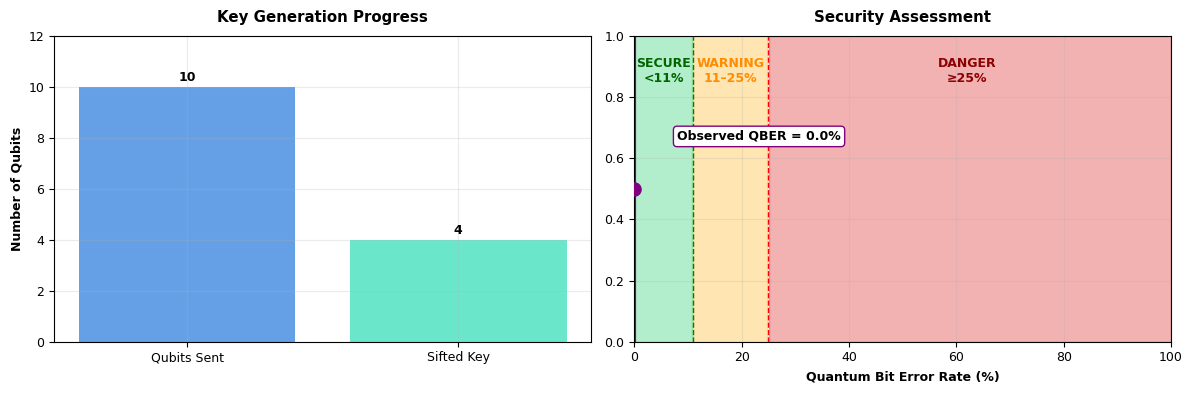

FINAL PROTOCOL SUMMARY
----------------------
Total qubits sent by Alice : 10
Sifted key length          : 4
Observed QBER              : 0.0%
Security decision          : SECURE (Noise-Limited)

Interpretation:
• Channel distance reduced the number of received photons
• Quantum disturbance from eavesdropping increased QBER
• High QBER indicates information leakage to an eavesdropper

Outcome:
• Secure quantum key successfully established
• Privacy amplification removed potential eavesdropper information

✓ BB84 simulation completed successfully.


In [ ]:
# ===============================
# STEP 10: Visualization & Final Results
# ===============================

print("STEP 10: Final Results & Visualization\n")

# -------------------------------
# Metrics from previous steps
# -------------------------------
bits_sent = num_qubits
bits_sifted = sifted_count
current_qber_percent = qber * 100

# -------------------------------
# Plot styling
# -------------------------------
plt.style.use('default')
plt.rc('font', size=9)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# ===============================
# Plot 1: Key Generation Progress
# ===============================
categories = ["Qubits Sent", "Sifted Key"]
values = [bits_sent, bits_sifted]
colors = ['#4A90E2', '#50E3C2']

bars = ax1.bar(categories, values, color=colors, alpha=0.85)
ax1.set_ylabel("Number of Qubits", fontweight='bold')
ax1.set_title("Key Generation Progress", fontweight='bold', pad=10)

for bar, value in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f'{value}',
             ha='center', va='bottom', fontweight='bold')

ax1.set_ylim(0, max(values) * 1.2)
ax1.grid(True, alpha=0.25)

# ===============================
# Plot 2: QBER Security Assessment
# ===============================
x = np.linspace(0, 100, 300)

ax2.fill_between(x, 0, 1, where=(x < 11), color='#00C853', alpha=0.3)
ax2.fill_between(x, 0, 1, where=(x >= 11) & (x < 25), color='#FFAB00', alpha=0.3)
ax2.fill_between(x, 0, 1, where=(x >= 25), color='#D50000', alpha=0.3)

ax2.axvline(11, color='green', linestyle='--', linewidth=1)
ax2.axvline(25, color='red', linestyle='--', linewidth=1)

ax2.text(5.5, 0.85, 'SECURE\n<11%', ha='center', fontweight='bold', color='darkgreen')
ax2.text(18, 0.85, 'WARNING\n11–25%', ha='center', fontweight='bold', color='darkorange')
ax2.text(62, 0.85, 'DANGER\n≥25%', ha='center', fontweight='bold', color='darkred')

# Current QBER marker
ax2.axvline(current_qber_percent, color='purple', linewidth=3)
ax2.scatter([current_qber_percent], [0.5], color='purple', s=90, zorder=5)

label_x = current_qber_percent
ha = 'center'
if current_qber_percent > 85:
    label_x -= 8
    ha = 'right'
elif current_qber_percent < 15:
    label_x += 8
    ha = 'left'

ax2.text(label_x, 0.65,
         f'Observed QBER = {current_qber_percent:.1f}%',
         ha=ha, va='bottom', fontweight='bold',
         bbox=dict(boxstyle="round,pad=0.3",
                   facecolor='white',
                   edgecolor='purple'))

ax2.set_xlim(0, 100)
ax2.set_ylim(0, 1)
ax2.set_xlabel("Quantum Bit Error Rate (%)", fontweight='bold')
ax2.set_title("Security Assessment", fontweight='bold', pad=10)
ax2.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

# ===============================
# Final protocol summary
# ===============================
print("FINAL PROTOCOL SUMMARY")
print("----------------------")
print(f"Total qubits sent by Alice : {bits_sent}")
print(f"Sifted key length          : {bits_sifted}")
print(f"Observed QBER              : {current_qber_percent:.1f}%")
print(f"Security decision          : {security_status}\n")

print("Interpretation:")
print("• Channel distance reduced the number of received photons")
print("• Quantum disturbance from eavesdropping increased QBER")
print("• High QBER indicates information leakage to an eavesdropper\n")

if security_status.startswith("SECURE"):
    print("Outcome:")
    print("• Secure quantum key successfully established")
    print("• Privacy amplification removed potential eavesdropper information\n")
else:
    print("Outcome:")
    print("• Channel security compromised")
    print("• Protocol correctly aborted to prevent key leakage\n")

print("✓ BB84 simulation completed successfully.")


## STEP 11: Encryption Using the Final Key (Alice)

### Purpose
In this step, Alice uses the **final secret key generated via BB84** to encrypt a classical message before sending it to Bob over a public (insecure) classical channel.

This step demonstrates **how quantum key distribution enables secure classical encryption**, even though the encryption itself is classical.

---

### Message Preparation
Alice begins with a plaintext message and converts it into a binary sequence using standard 8-bit ASCII encoding:

$$
\text{Character} \;\longrightarrow\; \text{8-bit binary representation}
$$

This produces a binary message stream:

$$
m_1, m_2, \dots, m_N \quad \text{where } m_i \in \{0,1\}
$$

---

### Encryption Method: Repeating XOR (Educational)
The message is encrypted using a **repeating XOR operation** with the final secret key:

$$
c_i = m_i \oplus k_{(i \bmod L)}
$$

where:
- $m_i$ is the $i$-th message bit  
- $k_j$ is the $j$-th key bit  
- $L$ is the length of the final key  
- $\oplus$ denotes the XOR operation  
- $c_i$ is the encrypted (ciphertext) bit  

If the message is longer than the key, the key bits are **reused cyclically**.

---

### Important Security Warning
⚠️ **This encryption scheme is used for demonstration only.**

- Repeating XOR is **not secure** for real-world communication  
- Reusing a key leaks information and is vulnerable to cryptanalysis  
- In practice, BB84 keys are used with secure symmetric ciphers such as:
  - AES
  - One-time pad (with no key reuse)

This implementation is intentionally simple to make the encryption process transparent.

---

### Demonstration Output
This step displays:
- A character-to-binary conversion table  
- Bit-by-bit XOR encryption for the first few bits  
- The final encrypted binary message (ciphertext)  

The ciphertext is the data Alice sends to Bob over the public channel.

---

### Clarifying the Quantum Interpretation
Classical XOR encryption **is not quantum encryption**.

However, there is a formal analogy:

$$
c = m \oplus k
$$

corresponds to applying a **Pauli-X operation conditioned on the key bit**:

$$
\lvert c \rangle = X^{k} \lvert m \rangle
$$

where:
- $\lvert m \rangle$ is the computational basis state of the message bit  
- $k \in \{0,1\}$ is the key bit  
- $X$ is the Pauli-X (bit-flip) operator  

This analogy helps connect classical encryption with quantum operators, but:

> **The encryption itself remains classical.**

---

### What Provides Security
- The **encryption algorithm is classical**
- The **security comes entirely from the BB84-generated key**
- BB84 ensures the key is:
  - random
  - shared securely
  - eavesdropper detectable if compromised

Without BB84, this encryption method would be insecure.

---

### Outcome
This step demonstrates how:
- Quantum key distribution enables secure key agreement
- Classical encryption can safely use that key
- Quantum mechanics protects the key, not the message channel

This completes the end-to-end BB84 communication workflow.


### Define the Message and Convert to Binary

First, Alice needs to define the message she wants to send and convert it into a sequence of bits (binary). Computers store all information as binary (0s and 1s).

In [ ]:
# --- STEP 12: Encryption using the Final Key (Alice) ---
print("STEP 12: Encrypting the message...")

# Define the message Alice wants to send
message = "HELLO TO THE QUANTUM WORLD"
print(f"Original Message: '{message}'")

# Convert the message to binary
# We'll represent each character as its 8-bit ASCII value
binary_message = ''.join(format(ord(char), '08b') for char in message)

# Display the binary conversion in a table for clarity
binary_conversion_data = []
for char in message:
    binary_conversion_data.append({'Character': char, 'ASCII Value': ord(char), 'Binary (8 bits)': format(ord(char), '08b')})

binary_conversion_df = pd.DataFrame(binary_conversion_data)

print("\nBinary Conversion Table:")
display(binary_conversion_df.style.hide(axis='index'))

print(f"Message in Binary: {binary_message}")
print(f"Message Length (bits): {len(binary_message)}")
print(f"Final Key Length (bits): {len(final_key)}")

print("✓ Message converted to binary.\n")

STEP 12: Encrypting the message...
Original Message: 'HELLO TO THE QUANTUM WORLD'

Binary Conversion Table:


Character,ASCII Value,Binary (8 bits)
H,72,01001000
E,69,01000101
L,76,01001100
L,76,01001100
O,79,01001111
,32,00100000
T,84,01010100
O,79,01001111
,32,00100000
T,84,01010100


Message in Binary: 0100100001000101010011000100110001001111001000000101010001001111001000000101010001001000010001010010000001010001010101010100000101001110010101000101010101001101001000000101011101001111010100100100110001000100
Message Length (bits): 208
Final Key Length (bits): 4
✓ Message converted to binary.



### Implement and Apply Repeating XOR Encryption

Now, Alice will use the `final_key` she generated with Bob. Since the key is likely shorter than the message, she will repeat the key from the beginning as needed to XOR with each bit of the binary message.

In [ ]:
# Implement the repeating XOR encryption function
def repeating_xor_encrypt(binary_message, binary_key):
    """
    Encrypts a binary message using a repeating XOR key.
    For educational demonstration only - NOT for secure use.
    """
    encrypted_binary = ""
    key_length = len(binary_key)
    if key_length == 0:
        print("Warning: Final key is empty. Cannot encrypt.")
        return binary_message # Return original if key is empty

    for i in range(len(binary_message)):
        # Get the bit from the message
        message_bit = int(binary_message[i])
        # Get the corresponding bit from the repeating key
        key_bit = binary_key[i % key_length] # Use modulo to repeat the key
        # Perform XOR operation
        encrypted_bit = message_bit ^ key_bit
        encrypted_binary += str(encrypted_bit)

    return encrypted_binary

# Ensure final_key is a list of integers (0 or 1)
# It should already be from Step 9, but this adds robustness
binary_final_key = [int(bit) for bit in final_key]


# Apply the repeating XOR encryption
encrypted_binary_message = repeating_xor_encrypt(binary_message, binary_final_key)

print(f"Original Binary Message (first 20 bits): {binary_message[:20]}...")
print(f"Binary Final Key: {binary_final_key}")
print(f"Encrypted Binary Message (first 20 bits): {encrypted_binary_message[:20]}...")


# Display the XOR process in a table for a few bits for clarity
xor_demonstration_data = []
num_bits_to_show = min(len(binary_message), 40) # Show up to 40 bits for better repetition view
key_length = len(binary_final_key)

for i in range(num_bits_to_show):
    message_bit = int(binary_message[i])
    key_bit = binary_final_key[i % key_length]
    encrypted_bit = int(encrypted_binary_message[i])

    # Add an indicator for the start of key repetition
    repetition_indicator = "*" if i > 0 and i % key_length == 0 else ""

    xor_demonstration_data.append({
        'Bit Index': i,
        'Message Bit': message_bit,
        'XOR (⊕)': '', # Add XOR symbol column
        'Key Bit (Repeated)': f"{key_bit} {repetition_indicator}", # Add indicator
        '=': '', # Add equals sign column
        'Encrypted Bit': encrypted_bit # Simplified column name
    })

xor_demonstration_df = pd.DataFrame(xor_demonstration_data)

print("\nRepeating XOR Encryption Demonstration (First few bits):")
# Use Styler to add visual flair (like centering) but hide index
styled_xor_df = xor_demonstration_df.style.hide(axis='index').set_properties(**{'text-align': 'center'})
display(styled_xor_df)

print("\n'*' indicates the start of a key repetition cycle.")
print("\n✓ Message encrypted using repeating XOR.\n")

Original Binary Message (first 20 bits): 01001000010001010100...
Binary Final Key: [1, 1, 1, 0]
Encrypted Binary Message (first 20 bits): 10100110101010111010...

Repeating XOR Encryption Demonstration (First few bits):


Bit Index,Message Bit,XOR (⊕),Key Bit (Repeated),=,Encrypted Bit
0,0,,1,,1
1,1,,1,,0
2,0,,1,,1
3,0,,0,,0
4,1,,1 *,,0
5,0,,1,,1
6,0,,1,,1
7,0,,0,,0
8,0,,1 *,,1
9,1,,1,,0



'*' indicates the start of a key repetition cycle.

✓ Message encrypted using repeating XOR.



### Display the Encrypted Message (Ciphertext)

The resulting `encrypted_binary_message` is the ciphertext that Alice would send to Bob. It looks like a random sequence of 0s and 1s to anyone who doesn't have the secret key.

In [ ]:
# Display the final encrypted binary message in a table
print("Final Encrypted Binary Message (Ciphertext):")

# Split the binary string into chunks for better display (e.g., 8 bits per chunk)
chunk_size = 8
binary_chunks = [encrypted_binary_message[i:i+chunk_size] for i in range(0, len(encrypted_binary_message), chunk_size)]

# Get the corresponding characters from the original message
original_chars = [message[i // chunk_size] for i in range(0, len(encrypted_binary_message), chunk_size)]


# Create a DataFrame for table display
ciphertext_df = pd.DataFrame({
    "Original Character": original_chars,
    "Encrypted Binary Chunks": binary_chunks
})

display(ciphertext_df.style.hide(axis='index'))


print("\nThis is the data Alice sends to Bob over the public channel.")
print("\n✓ Ciphertext displayed.\n")

Final Encrypted Binary Message (Ciphertext):


Original Character,Encrypted Binary Chunks
H,10100110
E,10101011
L,10100010
L,10100010
O,10100001
,11001110
T,10111010
O,10100001
,11001110
T,10111010



This is the data Alice sends to Bob over the public channel.

✓ Ciphertext displayed.



## STEP 12: Decryption Using the Final Key (Bob)

### Purpose
In this step, Bob decrypts the ciphertext received from Alice using the **same final secret key** established through the BB84 protocol.

This step completes the end-to-end communication workflow:
- Alice encrypts using the BB84 key  
- Bob decrypts using the identical BB84 key  

No quantum operations occur here; decryption is entirely classical.

---

### Why Decryption Works
The XOR operation has the key symmetry property:

$$
(m \oplus k) \oplus k = m
$$

where:
- $m$ is the original message bit  
- $k$ is the key bit  
- $\oplus$ denotes the XOR operation  

Because Alice and Bob share the **same key**, Bob can reverse the encryption by applying XOR again.

---

### Decryption Procedure
Given:
- Encrypted binary message:
$$
c_1, c_2, \dots, c_N
$$

- Final secret key:
$$
k_1, k_2, \dots, k_L
$$

Bob computes each decrypted bit as:

$$
m_i = c_i \oplus k_{(i \bmod L)}
$$

If the ciphertext is longer than the key, the key bits are reused cyclically, exactly as in encryption.

---

### Demonstration Output
This step displays:

- Bit-by-bit XOR decryption for the first few bits  
- Clear indication of where key repetition begins  
- The fully decrypted binary message  

These tables visually confirm that applying XOR with the same key reverses the encryption.

---

### Binary-to-Text Conversion
The decrypted binary string is then converted back into text:

- The binary stream is split into 8-bit chunks  
- Each chunk is interpreted as an ASCII value  
- Characters are reconstructed to form the plaintext message  

Formally:

$$
\text{Binary (8 bits)} \;\longrightarrow\; \text{ASCII character}
$$

---

### Verification
The decrypted message is compared with Alice’s original plaintext.

If:
$$
\text{Decrypted message} = \text{Original message}
$$

then the decryption is successful.

This verification confirms:
- Correct key agreement via BB84  
- Correct encryption and decryption logic  
- No data corruption during transmission  

---

### Important Security Note
⚠️ **This decryption method is for educational demonstration only.**

- Repeating XOR is **not cryptographically secure**
- Key reuse leaks information
- Real systems combine BB84 keys with secure ciphers (e.g., AES)

The security in this demonstration comes entirely from **BB84 key establishment**, not from the XOR algorithm itself.

---

### Outcome
This step demonstrates that:

- Quantum Key Distribution enables secure key sharing  
- Classical encryption and decryption can safely rely on that key  
- Bob can perfectly recover Alice’s message when no security violation occurs  

This completes the full BB84 based secure communication pipeline.


### Implement and Apply Repeating XOR Decryption

Bob uses the same repeating XOR function as Alice, applying the shared `final_key` to the received `encrypted_binary_message`.

In [ ]:
# Implement the repeating XOR decryption function
# For XOR, the decryption function is the same as the encryption function
def repeating_xor_decrypt(encrypted_binary_message, binary_key):
    """
    Decrypts a binary message using a repeating XOR key.
    For educational demonstration only - NOT for secure use.
    """
    decrypted_binary = ""
    key_length = len(binary_key)
    if key_length == 0:
        print("Warning: Final key is empty. Cannot decrypt.")
        return encrypted_binary_message # Return original if key is empty

    for i in range(len(encrypted_binary_message)):
        # Get the bit from the encrypted message
        encrypted_bit = int(encrypted_binary_message[i])
        # Get the corresponding bit from the repeating key
        key_bit = binary_key[i % key_length] # Use modulo to repeat the key
        # Perform XOR operation (encryption and decryption are the same for XOR)
        decrypted_bit = encrypted_bit ^ key_bit
        decrypted_binary += str(decrypted_bit)

    return decrypted_binary

# Bob already has the binary_final_key from the BB84 protocol exchange

# Apply the repeating XOR decryption
decrypted_binary_message = repeating_xor_decrypt(encrypted_binary_message, binary_final_key)

print("Applying repeating XOR decryption...")
print(f"Received Encrypted Binary Message (first 20 bits): {encrypted_binary_message[:20]}...")
print(f"Binary Final Key (used repeatedly): {binary_final_key}")
print(f"Decrypted Binary Message (first 20 bits): {decrypted_binary_message[:20]}...")


# Display the XOR process for decryption in a table for a few bits
xor_decryption_demonstration_data = []
num_bits_to_show = min(len(encrypted_binary_message), 40) # Show up to 40 bits

for i in range(num_bits_to_show):
    encrypted_bit = int(encrypted_binary_message[i])
    key_bit = binary_final_key[i % len(binary_final_key)]
    decrypted_bit = int(decrypted_binary_message[i])

     # Add an indicator for the start of key repetition
    repetition_indicator = "*" if i > 0 and i % len(binary_final_key) == 0 else ""


    xor_decryption_demonstration_data.append({
        'Bit Index': i,
        'Encrypted Bit': encrypted_bit,
        'XOR (⊕)': '', # Add XOR symbol column
        'Key Bit (Repeated)': f"{key_bit} {repetition_indicator}", # Add indicator
        '=': '', # Add equals sign column
        'Decrypted Bit': decrypted_bit
    })

xor_decryption_demonstration_df = pd.DataFrame(xor_decryption_demonstration_data)

print("\nRepeating XOR Decryption Demonstration (First few bits):")
# Use Styler for centering
styled_xor_decryption_df = xor_decryption_demonstration_df.style.hide(axis='index').set_properties(**{'text-align': 'center'})
display(styled_xor_decryption_df)

print("\n'*' indicates the start of a key repetition cycle.")
print("\n✓ Decryption process applied.\n")

Applying repeating XOR decryption...
Received Encrypted Binary Message (first 20 bits): 10100110101010111010...
Binary Final Key (used repeatedly): [1, 1, 1, 0]
Decrypted Binary Message (first 20 bits): 01001000010001010100...

Repeating XOR Decryption Demonstration (First few bits):


Bit Index,Encrypted Bit,XOR (⊕),Key Bit (Repeated),=,Decrypted Bit
0,1,,1,,0
1,0,,1,,1
2,1,,1,,0
3,0,,0,,0
4,0,,1 *,,1
5,1,,1,,0
6,1,,1,,0
7,0,,0,,0
8,1,,1 *,,0
9,0,,1,,1



'*' indicates the start of a key repetition cycle.

✓ Decryption process applied.



### Convert Decrypted Binary Back to Text

Now that Bob has the decrypted message in binary form, he converts it back into readable text characters.

In [ ]:
# Convert the decrypted binary message back to text
def binary_to_text(binary_string):
    """
    Converts a binary string back into a text string.
    Assumes the binary string is a multiple of 8 bits.
    """
    text = ""
    # Split the binary string into 8-bit chunks
    for i in range(0, len(binary_string), 8):
        byte = binary_string[i:i+8]
        # Convert each 8-bit chunk to an integer, then to a character
        text += chr(int(byte, 2))
    return text

decrypted_message = binary_to_text(decrypted_binary_message)

print("Converting decrypted binary back to text...")
print(f"Decrypted Binary Message (first 20 bits): {decrypted_binary_message[:20]}...")
print(f"Decrypted Text Message: '{decrypted_message}'")

print("\n✓ Decrypted binary converted to text.\n")

Converting decrypted binary back to text...
Decrypted Binary Message (first 20 bits): 01001000010001010100...
Decrypted Text Message: 'HELLO TO THE QUANTUM WORLD'

✓ Decrypted binary converted to text.



### Verify Decryption

Finally, Bob can compare the decrypted message to the original message (if he had a way to verify, like a known plaintext attack or a hash - in this simulation, we know the original for verification). This step confirms that the decryption was successful and the shared key was correct.

In [ ]:
# Verify that the decrypted message matches the original message
print("Verifying decryption...")

original_message_check = "HELLO TO THE QUANTUM WORLD" # Use the original message defined in Step 12

if decrypted_message == original_message_check:
    print("✅ Decryption successful! The decrypted message matches the original message.")
else:
    print("❌ Decryption failed. The decrypted message does NOT match the original message.")
    print(f"Original: '{original_message_check}'")
    print(f"Decrypted: '{decrypted_message}'")

print("\n✓ Decryption verified.\n")

Verifying decryption...
✅ Decryption successful! The decrypted message matches the original message.

✓ Decryption verified.

